## 模型

In [2]:
col_hf = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']
col_lf = ['FA_ROE_AVG', 'FA_ORGR_TTM', 'FA_DEBTTOASSET', "PE_TTM","WEST_SALES_FTM_CHG_3M", "WEST_NETPROFIT_FTM_CHG_3M"]
target = 'target_return'

In [ ]:
# 融合模型
import torch.nn as nn
import torch.nn.functional as F

class QuantHybridModel(nn.Module):
    def __init__(self, hf_input_dim=5, lf_input_dim=6, window_size=20, hidden_dim=128):
        super(QuantHybridModel, self).__init__()
        
        # ====================
        # 分支 1: 高频时序网络
        # ====================
        #  CNN 层 (提取局部特征，如 3 天内的 K 线组合)
        # 输入 (Batch, Channels, Length) -> PyTorch Conv1d 要求通道在中间
        self.conv = nn.Conv1d(in_channels=hf_input_dim, out_channels=32, kernel_size=3, padding=0)
        
        #  LSTM 层
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        
        
        # ====================
        # 分支 2: 低频基本面网络
        # ====================
        # MLP 层
        self.mlp = nn.Sequential(
            nn.Linear(lf_input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16)
        )
        

        # 3. Attention 层
        combined_dim = hidden_dim + 16 # 128 + 16 = 144
        self.attn_weights = nn.Sequential(
            nn.Linear(combined_dim, combined_dim),
            nn.ReLU(),
            nn.Linear(combined_dim, combined_dim),
            nn.Sigmoid() # 使用 Sigmoid 阀门控制每个特征的去留
        )


        # ====================
        # 融合层 (Fusion)
        # ====================
        # 将 Attention的上下文向量 (hidden_dim) 和 MLP输出 (16) 拼接
        self.fc = nn.Sequential(
            nn.BatchNorm1d(hidden_dim + 16),
            nn.Linear(hidden_dim + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1) # 最终预测下一期收益率
        )
        self.post_attn_dropout = nn.Dropout(0.3)

    def forward(self, x_hf, x_lf):
        # --- 高频分支前向传播 ---
        # x_hf 初始形状: (Batch, Seq_len, Features) -> (B, 20, 5)
        # 适应 Conv1d 转换为: (Batch, Features, Seq_len) -> (B, 5, 20)
        x_hf = x_hf.permute(0, 2, 1) 
        x_hf = F.relu(self.conv(x_hf))
        
        # 适应 LSTM 再转回: (Batch, Seq_len, Conv_out) -> (B, 20, 32)
        x_hf = x_hf.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x_hf) # lstm_out: (B, 20, 128)
        
        # 输出高频特征
        hf_feature = lstm_out[:, -1, :]

        # --- 低频分支前向传播 ---
        # x_lf 形状: (Batch, Features) -> (B, 6)
        lf_feature = self.mlp(x_lf) # 输出: (B, 16)
       
        # --- 特征融合与输出 ---
        # 形状变化: (B, 128) + (B, 16) -> (B, 80)
        combined = torch.cat((hf_feature, lf_feature), dim=1)
        # 计算全局权重 (B, 80) -> (B, 80)
        # 这里 self.attn_weights 需要重新定义，输入输出维度都是 80
        attn_scores = self.attn_weights(combined) 
        attn_weights = torch.sigmoid(attn_scores) # 或者 Softmax，看你想让它们竞争还是独立
        
        # 元素级加权
        weighted_combined = combined * attn_weights
        weighted_combined = self.post_attn_dropout(weighted_combined)
        # --- 4. 最终输出 ---
        output = self.fc(weighted_combined)
        return output, attn_weights
    
# 实例化模型
model = QuantHybridModel(hf_input_dim=len(col_hf), lf_input_dim=len(col_lf))
print(model)

QuantHybridModel(
  (conv): Conv1d(5, 32, kernel_size=(3,), stride=(1,))
  (lstm): LSTM(32, 128, batch_first=True)
  (mlp): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
  )
  (attn_weights): Sequential(
    (0): Linear(in_features=144, out_features=144, bias=True)
    (1): ReLU()
    (2): Linear(in_features=144, out_features=144, bias=True)
    (3): Sigmoid()
  )
  (fc): Sequential(
    (0): BatchNorm1d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=144, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
  (post_attn_dropout): Dropout(p=0.3, inplace=False)
)


In [23]:
# 时序模型
import torch
import torch.nn as nn
import torch.nn.functional as F

class AblationModel(nn.Module):
    def __init__(self, hf_input_dim=5, window_size=20, hidden_dim=128):
        super(AblationModel, self).__init__()
        
        # 1. CNN 层：提取局部时序特征 (如 3 日 K 线形态)
        # 输入: (Batch, 5, 20) -> 输出: (Batch, 32, 18) [因为 kernel=3, pad=0]
        self.conv = nn.Conv1d(in_channels=hf_input_dim, out_channels=32, kernel_size=3, padding=0)
        
        # 2. LSTM 层：捕捉长程依赖
        # 输入 size 是 CNN 的输出通道数 32
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        
        # 3. Attention 层 (时间维度注意力)
        # 作用：学习在经过 CNN/LSTM 处理后的序列中，哪一个时间点对预测收益率最重要
        self.attention_net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # 4. 预测输出层
        self.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_hf):
        # --- 1. CNN 部分 ---
        # x_hf shape: (Batch, Seq_len, Features) -> (B, 20, 5)
        # 转换为 Conv1d 要求: (Batch, Features, Seq_len) -> (B, 5, 20)
        x = x_hf.permute(0, 2, 1) 
        x = F.relu(self.conv(x)) # 输出: (B, 32, 18)
        
        # --- 2. LSTM 部分 ---
        # 转换回 LSTM 要求: (Batch, Seq_len_new, Conv_out) -> (B, 18, 32)
        x = x.permute(0, 2, 1)
        lstm_out, (h_n, c_n) = self.lstm(x) # lstm_out: (B, 18, hidden_dim)
        
        # --- 3. Attention 部分 ---
        # 计算每个时间步的权重
        attn_logits = self.attention_net(lstm_out) # (B, 18, 1)
        attn_weights = F.softmax(attn_logits, dim=1) # 在时间维度做归一化
        
        # 对 LSTM 的所有隐藏状态进行加权求和 (Temporal Pooling)
        # (B, 18, hidden_dim) * (B, 18, 1) -> (B, hidden_dim)
        context_vector = torch.sum(lstm_out * attn_weights, dim=1)
        
        # --- 4. 输出层 ---
        output = self.fc(context_vector)
        return output.squeeze(-1), attn_weights

# 实例化
model = AblationModel(hf_input_dim=len(col_hf))
print(model)

AblationModel(
  (conv): Conv1d(5, 32, kernel_size=(3,), stride=(1,))
  (lstm): LSTM(32, 128, batch_first=True)
  (attention_net): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=128, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 提取数据

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class QuantDataset(Dataset):
    def __init__(self, df, col_hf, col_lf, target, window_size=20):
        # 1. 确保数据按股票和时间排序，这是滑动窗口的基础
        df = df.sort_values(['code', 'date'])
        
        # 2. 将数据转换为 numpy 数组提高索引速度
        self.hf_data = df[col_hf].values.astype(np.float32)
        self.lf_data = df[col_lf].values.astype(np.float32)
        self.targets = df[target].values.astype(np.float32)
        
        # 3. 记录每只股票的索引范围，防止滑动窗口跨越两只不同的股票
        self.valid_indices = []
        codes = df['code'].values
        # 找到每只股票开始的索引位置
        _, start_indices = np.unique(codes, return_index=True)
        end_indices = np.append(start_indices[1:], len(df))
        
        for start, end in zip(start_indices, end_indices):
            # 只有长度大于窗口大小的股票才有有效窗口
            if end - start >= window_size:
                # 记录该股票下所有可用的结束位置索引
                for i in range(start + window_size - 1, end):
                    self.valid_indices.append(i)
        
        self.window_size = window_size

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # 获取当前样本在原始 DataFrame 中的实际索引位置
        actual_idx = self.valid_indices[idx]
        
        # 高频特征：取过去 window_size 天的序列 (T, F)
        x_hf = self.hf_data[actual_idx - self.window_size + 1 : actual_idx + 1]
        
        # 低频特征：只取当前时刻 (F,)
        x_lf = self.lf_data[actual_idx]
        
        # 标签
        y = self.targets[actual_idx]
        
        return torch.from_numpy(x_hf), torch.from_numpy(x_lf), torch.tensor([y])

In [82]:
# 读取数据
import pandas as pd
df_cleaned = pd.read_parquet('data/cleaned_300.parquet')
df_cleaned = df_cleaned.dropna(subset=[target])
print(df_cleaned.head(5))
print(len(df_cleaned))

# 切分训练集和测试集
# 确保 date 列是 datetime 格式
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
# 获取所有交易日并排序
all_dates = df_cleaned['date'].sort_values().unique()
# 计算分割点的索引
train_split_idx = int(len(all_dates) * 0.9)
# 得到具体的分割日期
train_end_date = all_dates[train_split_idx]


print(f"训练集期间: 开始 到 {train_end_date.strftime('%Y-%m-%d')}")
print(f"验证集期间: {train_end_date.strftime('%Y-%m-%d')} 到 结束")


# 按日期切分 DataFrame
df_train = df_cleaned[df_cleaned['date'] < train_end_date].copy()
df_val = df_cleaned[df_cleaned['date'] >= train_end_date].copy()

# 实例化数据集
train_dataset = QuantDataset(df_train, col_hf, col_lf, target, window_size=20)
val_dataset = QuantDataset(df_val, col_hf, col_lf, target, window_size=20)
all_dataset = QuantDataset(df_cleaned, col_hf, col_lf, target, window_size=20)

# 创建 DataLoader
# shuffle=True 仅在训练集使用，打破时序相关性有助于模型泛化
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, num_workers=0)
all_loader = DataLoader(all_dataset, batch_size=1024, shuffle=False, num_workers=0)

        date  WEST_NETPROFIT_FY1_CHG_3M  WEST_NETPROFIT_FTM_CHG_3M  \
0 2016-01-29              -6.002894e+07                   0.182098   
1 2016-02-01              -6.002894e+07                   0.183956   
2 2016-02-02              -6.002894e+07                   0.184575   
3 2016-02-03              -6.002894e+07                   0.185194   
4 2016-02-04              -6.002894e+07                   0.185813   

   WEST_SALES_FY1_3M  WEST_SALES_FTM_CHG_3M  VAL_AVGPE_SW    PE_TTM  \
0           0.599239               0.260246        6.1239 -0.473854   
1           0.599239               0.260712        6.0169 -0.475900   
2           0.599239               0.260868        6.0808 -0.474365   
3           0.599239               0.261023        6.0249 -0.475389   
4           0.599239               0.261179        6.0988 -0.474365   

   VAL_STDPE_SW  DFA_TLTSHARE  FA_ROE_AVG  ...  FA_CTOP       code  \
0        0.7118  1.430868e+10    0.708562  ...      NaN  000001.SZ   
1        0.7

In [83]:
import torch
import numpy as np

# 1. 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 加载你存好的模型权重
# 注意：QuantHybridModel 必须是已经修改过 forward 函数（返回两个值）的版本
model = QuantHybridModel(hf_input_dim=len(col_hf), lf_input_dim=len(col_lf)).to(device)
model.load_state_dict(torch.load('merged_final.pth', map_location=device)) # 确认你的文件名
model.eval()

all_weights = []
all_preds = []
all_targets = []

print("开始从验证集提取数据...")
with torch.no_grad():
    for x_hf, x_lf, y in val_loader:
        x_hf, x_lf = x_hf.to(device), x_lf.to(device)
        
        # 运行模型：得到预测值和 144 维的 Attention 权重
        y_pred, weights = model(x_hf, x_lf)
        
        all_weights.append(weights.cpu().numpy())
        all_preds.append(y_pred.cpu().numpy().flatten())
        all_targets.append(y.numpy().flatten())

# 将所有 batch 合并
weights_final = np.concatenate(all_weights, axis=0) # 形状: (样本数, 144)
preds_final = np.concatenate(all_preds, axis=0)    # 形状: (样本数,)
targets_final = np.concatenate(all_targets, axis=0) # 形状: (样本数,)

print(f"提取完成！共得到 {len(preds_final)} 个样本的预测数据。")

开始从验证集提取数据...
提取完成！共得到 64972 个样本的预测数据。


In [84]:
# 提取时序模型
import torch
import numpy as np

# 1. 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 加载你存好的模型权重
# 注意：QuantHybridModel 必须是已经修改过 forward 函数（返回两个值）的版本
model = AblationModel(hf_input_dim=len(col_hf)).to(device)
model.load_state_dict(torch.load('time_final.pth', map_location=device)) # 确认你的文件名
model.eval()

all_weights = []
all_preds = []
all_targets = []

print("开始从验证集提取数据...")
with torch.no_grad():
    for x_hf, x_lf, y in val_loader:
        x_hf, x_lf = x_hf.to(device), x_lf.to(device)
        
        # 运行模型：得到预测值和 144 维的 Attention 权重
        y_pred, weights = model(x_hf)
        
        all_weights.append(weights.cpu().numpy())
        all_preds.append(y_pred.cpu().numpy().flatten())
        all_targets.append(y.numpy().flatten())

# 将所有 batch 合并
weights_final_time = np.concatenate(all_weights, axis=0) # 形状: (样本数, 144)
preds_final_time = np.concatenate(all_preds, axis=0)    # 形状: (样本数,)
targets_final_time = np.concatenate(all_targets, axis=0) # 形状: (样本数,)

print(f"提取完成！共得到 {len(preds_final_time)} 个样本的预测数据。")

开始从验证集提取数据...
提取完成！共得到 64972 个样本的预测数据。


/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/313571655.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_fin_weights, y=col_lf, palette="viridis")
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36130 (\N{CJK UNIFIED IDEOGRAPH-8D22}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21153 (\N{CJK UNIFIED IDEOGRAPH-52A1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.13/site-packages/IPython/core/

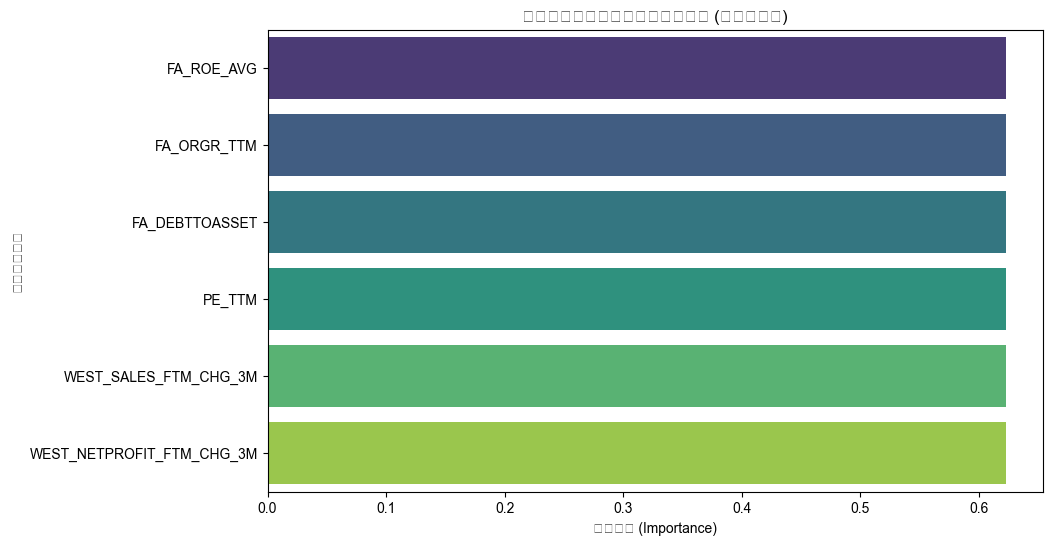

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['axes.unicode_minus'] = False

# 计算最后 6 个财务因子的平均权重
avg_fin_weights = np.mean(weights_final[:, -6:], axis=0)

plt.figure(figsize=(10, 6))
# col_lf 是你代码里定义的财务特征列名列表
sns.barplot(x=avg_fin_weights, y=col_lf, palette="viridis")

plt.title("会计基本面指标的注意力权重分布 (验证集平均)")
plt.xlabel("平均权重 (Importance)")
plt.ylabel("财务指标名称")
plt.show()

In [86]:
# 1. 将预测结果放回原 DataFrame 的验证集部分，方便按日期分组
# 假设 df_val 的长度和 preds_final 一致（由于 window_size 可能会少一点点，请注意对齐）
# 计算差额
diff_merged = len(df_val) - len(preds_final)
print(f"原始数据比预测值多出 {diff_merged} 行")
diff_time = len(df_val) - len(preds_final_time)
print(f"原始数据比时序模型预测值多出 {diff_time} 行")

# 截取 df_val 的后半部分，使其长度与 preds_final 完全一致
df_result = df_val.iloc[diff_merged:].copy()

# 现在赋值就不会报错了

df_result['pred_score'] = preds_final
df_result['pred_score_time'] = preds_final_time

原始数据比预测值多出 5472 行
原始数据比时序模型预测值多出 5472 行


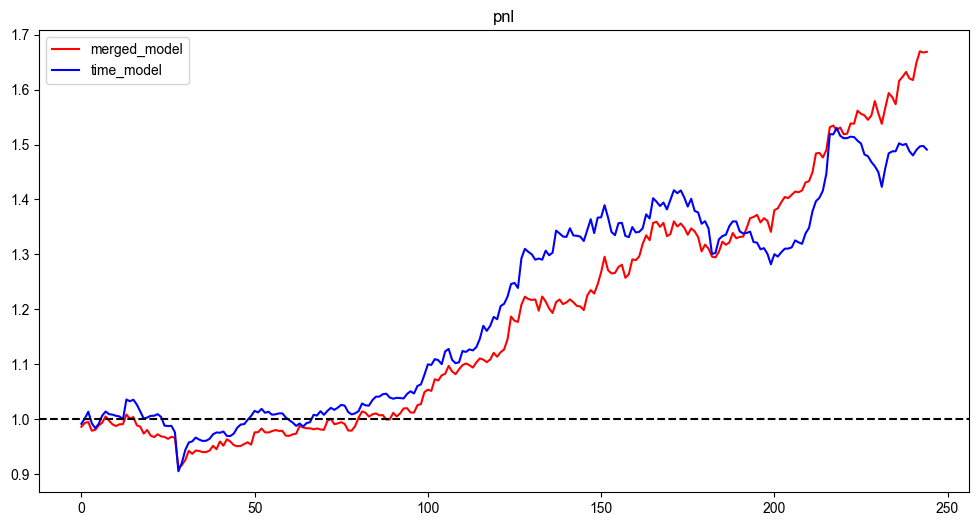

In [87]:


# 2. 计算每日策略收益
# 策略：每天选出预测得分最高的前 window 只股票，买入并持有到第二天
daily_returns_merged = []
daily_returns_time = []
window = 10 # 每天选出前 window 只股票
dates = sorted(df_result['date'].unique())

for d in dates:
    day_data = df_result[df_result['date'] == d]
    # 选出得分最高的前 window 只
    top_stocks_merged = day_data.nlargest(window, 'pred_score')
    top_stocks_time = day_data.nlargest(window, 'pred_score_time')
    # 计算这 window 只股票当天的平均实际收益 (target 通常就是下一期收益)
    daily_returns_merged.append(top_stocks_merged[target].mean())
    daily_returns_time.append(top_stocks_time[target].mean())
# 3. 计算累计净值
strat_nav_merged = (1 + pd.Series(daily_returns_merged)).cumprod()
strat_nav_time = (1 + pd.Series(daily_returns_time)).cumprod()


# 4. 绘图
plt.figure(figsize=(12, 6))
plt.plot(strat_nav_merged.values, label='merged_model', color='red')
plt.plot(strat_nav_time.values, label='time_model', color='blue')
plt.axhline(y=1, color='black', linestyle='--') # 基准线
plt.title("pnl")
plt.legend()
plt.show()

/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/3995392473.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_returns = df_result.groupby('date').apply(
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
fi

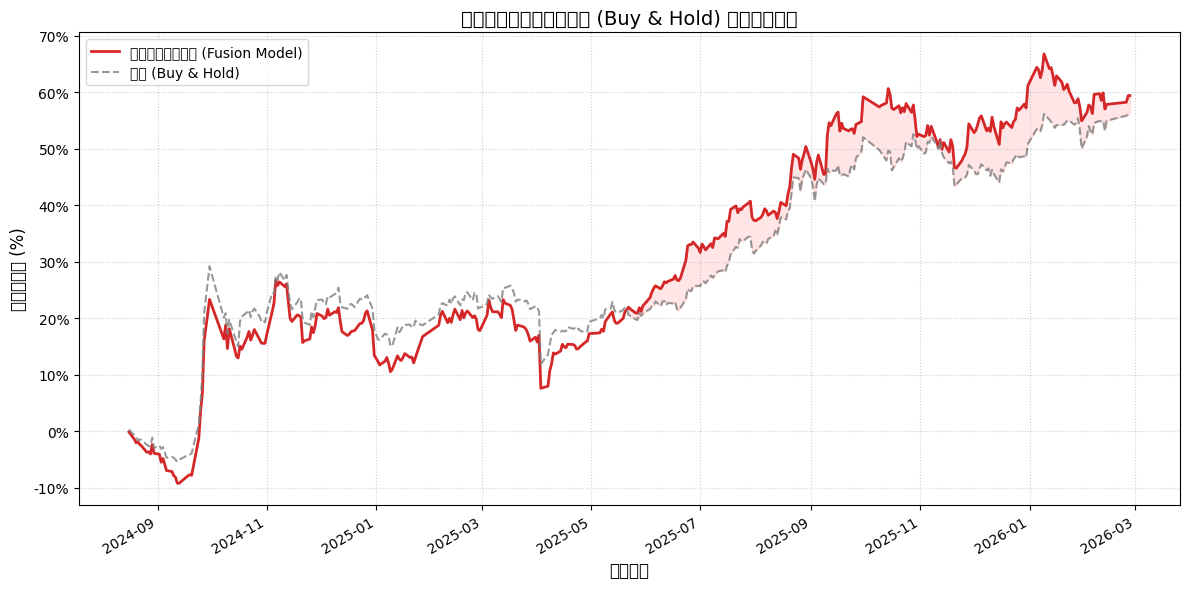

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def plot_refined_nav(df_result, target_col='target'):
    """
    df_result: 已经对齐好 pred_score 的 DataFrame
    target_col: 你定义的下一期收益率列名
    """
    # 1. 确保日期是日期格式并排序
    df_result['date'] = pd.to_datetime(df_result['date'])
    df_result = df_result.sort_values('date')
    
    # 2. 计算策略收益 (Strategy: 每日选前10只)
    strat_returns = df_result.groupby('date').apply(
        lambda x: x.nlargest(10, 'pred_score')[target_col].mean()
    )
    
    # 3. 计算 Buy and Hold 基准收益 (沪深300成分股等权平均)
    # 论文中通常用验证集内所有股票的等权平均作为基准，或者直接用指数
    benchmark_returns = df_result.groupby('date')[target_col].mean()
    
    # 4. 计算累计净值 (Cumulative Returns)
    # 初始设为 0%
    strat_nav = (1 + strat_returns).cumprod() - 1
    benchmark_nav = (1 + benchmark_returns).cumprod() - 1
    
    # 5. 开始绘图
    plt.figure(figsize=(12, 6))
    plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决中文乱码
    plt.rcParams['axes.unicode_minus'] = False 

    # 画图
    plt.plot(strat_nav.index, strat_nav.values, label='本文融合模型策略 (Fusion Model)', color='#d62728', linewidth=2)
    plt.plot(benchmark_nav.index, benchmark_nav.values, label='基准 (Buy & Hold)', color='#7f7f7f', linestyle='--', alpha=0.8)
    
    # 填充超额收益区域
    plt.fill_between(strat_nav.index, strat_nav.values, benchmark_nav.values, 
                     where=(strat_nav.values > benchmark_nav.values), color='red', alpha=0.1)

    # 6. 格式化 Y 轴为百分比
    fmt = '%.0f%%' # 设置百分比格式
    yticks = mtick.FormatStrFormatter(fmt)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # 7. 细节打磨
    plt.title("验证集内模型策略与基准 (Buy & Hold) 收益走势对比", fontsize=14)
    plt.xlabel("交易日期", fontsize=12)
    plt.ylabel("累计收益率 (%)", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 自动调整 X 轴日期倾斜
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.savefig('strategy_performance.png', dpi=300)
    plt.show()

# 调用函数
plot_refined_nav(df_result, target_col=target)

/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/951657473.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(
/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/951657473.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(


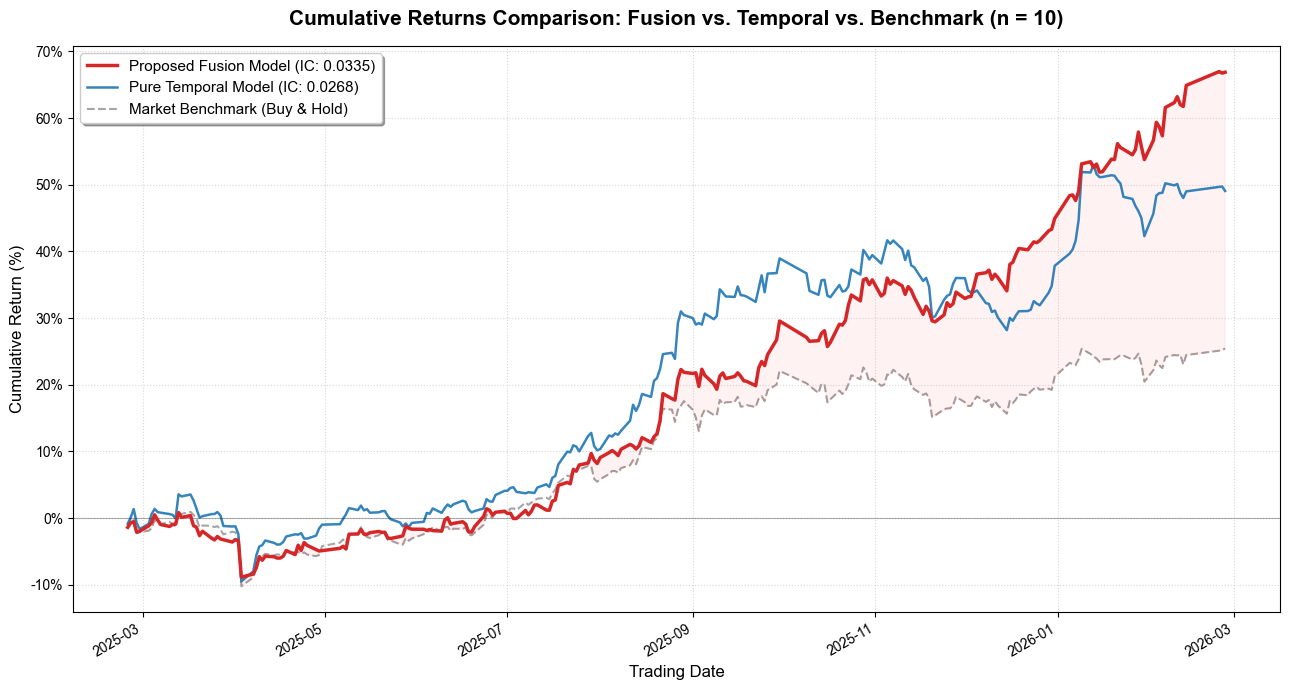

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def plot_triple_comparison(df_result, fusion_col='pred_score_fusion', temporal_col='pred_score_temporal', target_col='target', m =10):
    """
    df_result: 包含两个模型预测分和实际收益的 DataFrame
    fusion_col: 融合模型的预测分列名
    temporal_col: 纯时序模型的预测分列名
    target_col: 下一期收益率列名 (如 'target')
    """
    # 1. 预处理：确保日期格式与排序
    df_result['date'] = pd.to_datetime(df_result['date'])
    df_result = df_result.sort_values('date')
    
    # 2. 定义策略计算函数 (Top 10 选股)
    def get_top_n_returns(df, score_col, n=m):
        return df.groupby('date').apply(
            lambda x: x.nlargest(n, score_col)[target_col].mean()
        )

    # 3. 计算三类收益率序列
    # (A) 融合模型策略收益
    returns_fusion = get_top_n_returns(df_result, fusion_col)
    # (B) 纯时序模型策略收益
    returns_temporal = get_top_n_returns(df_result, temporal_col)
    # (C) Buy & Hold 基准收益 (验证集内所有股票等权平均)
    returns_bh = df_result.groupby('date')[target_col].mean()

    # 4. 计算累计收益率 (Cumulative Returns, 初始为 0)
    nav_fusion = (1 + returns_fusion).cumprod() - 1
    nav_temporal = (1 + returns_temporal).cumprod() - 1
    nav_bh = (1 + returns_bh).cumprod() - 1

    # 5. 绘图设置 (字体设为英文常用学术字体)
    plt.figure(figsize=(13, 7))
    plt.rcParams['font.family'] = 'Arial' # 使用英文 Arial 字体
    plt.rcParams['axes.unicode_minus'] = False 

    # --- 开始画线 ---
    # 融合模型 (突出显示)
    plt.plot(nav_fusion.index, nav_fusion.values, 
             label='Proposed Fusion Model (IC: 0.0335)', 
             color='#d62728', linewidth=2.5, zorder=3)
    
    # 纯时序模型
    plt.plot(nav_temporal.index, nav_temporal.values, 
             label='Pure Temporal Model (IC: 0.0268)', 
             color='#1f77b4', linewidth=1.8, alpha=0.9, zorder=2)
    
    # Buy & Hold 基准
    plt.plot(nav_bh.index, nav_bh.values, 
             label='Market Benchmark (Buy & Hold)', 
             color='#7f7f7f', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

    # 6. 填充超额收益区域 (Fusion vs B&H)
    plt.fill_between(nav_fusion.index, nav_fusion.values, nav_bh.values, 
                     where=(nav_fusion.values > nav_bh.values), 
                     color='red', alpha=0.05)

    # 7. 格式化 Y 轴为百分比
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # 8. 图表细节 (全英文)
    plt.title(f"Cumulative Returns Comparison: Fusion vs. Temporal vs. Benchmark (n = {m})", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Trading Date", fontsize=12)
    plt.ylabel("Cumulative Return (%)", fontsize=12)
    plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    # 自动调整 X 轴日期倾斜
    plt.gcf().autofmt_xdate()
    
    # 添加一条 0% 的基准线
    plt.axhline(y=0, color='black', linewidth=0.8, alpha=0.3)

    plt.tight_layout()
    plt.savefig('model_comparison_nav.png', dpi=300)
    plt.show()

# 调用示例 (请确保你的 df_result 已经按照之前的 align 逻辑对齐了两个模型的 score)
plot_triple_comparison(df_result, fusion_col='pred_score', temporal_col='pred_score_time', target_col=target)

/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/3081559035.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(
/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/3081559035.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('date').apply(



策略表现统计表 (Performance Metrics)
--------------------------------------------------
                 年化收益率 (%)   夏普比率  最大回撤 (%)  Alpha
策略 (Strategy)                                     
沪深300基准             26.241  1.622   -11.052  0.000
技术强化策略(Model-T)     64.187  1.717   -14.874  0.379
融合策略(Model-F)      144.705  2.982   -12.913  1.185



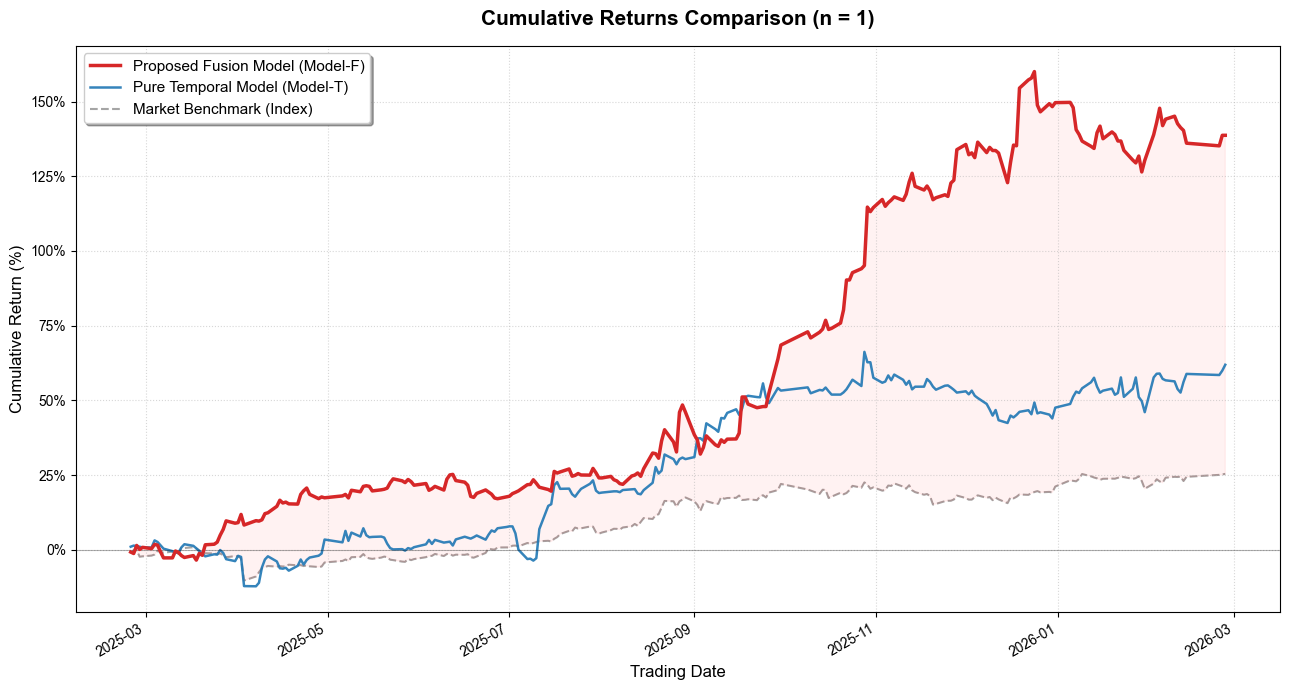

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def plot_triple_comparison(df_result, fusion_col='pred_score_fusion', temporal_col='pred_score_temporal', target_col='target', m=10):
    """
    df_result: 包含两个模型预测分和实际收益的 DataFrame
    fusion_col: 融合模型的预测分列名
    temporal_col: 纯时序模型的预测分列名
    target_col: 下一期收益率列名 (如 'target')
    m: 选股数量
    """
    # 1. 预处理
    df_result['date'] = pd.to_datetime(df_result['date'])
    df_result = df_result.sort_values('date')
    
    # 2. 定义策略计算逻辑
    def get_top_n_returns(df, score_col, n=m):
        return df.groupby('date').apply(
            lambda x: x.nlargest(n, score_col)[target_col].mean()
        )

    # 3. 计算日收益率序列 (Daily Returns)
    ret_fusion = get_top_n_returns(df_result, fusion_col)
    ret_temporal = get_top_n_returns(df_result, temporal_col)
    ret_bench = df_result.groupby('date')[target_col].mean() # 市场基准

    # --- 新增：量化指标计算逻辑 ---
    def calculate_stats(returns, benchmark_returns, name):
        # 交易日天数（通常一年252天）
        days = len(returns)
        ann_factor = 252
        
        # 年化收益率
        cum_ret = (1 + returns).prod()
        ann_ret = (cum_ret ** (ann_factor / days)) - 1
        
        # 夏普比率 (假设无风险利率为0)
        sharpe = (returns.mean() * ann_factor) / (returns.std() * np.sqrt(ann_factor))
        
        # 最大回撤
        nav = (1 + returns).cumprod()
        max_drawdown = ((nav.cummax() - nav) / nav.cummax()).max()
        
        # Alpha (简易超额年化收益)
        bench_cum_ret = (1 + benchmark_returns).prod()
        bench_ann_ret = (bench_cum_ret ** (ann_factor / days)) - 1
        alpha = ann_ret - bench_ann_ret
        
        return {
            "策略 (Strategy)": name,
            "年化收益率 (%)": ann_ret * 100,
            "夏普比率": sharpe,
            "最大回撤 (%)": -max_drawdown * 100, # 通常显示为负值
            "Alpha": alpha
        }

    # 生成统计表格
    stats = [
        calculate_stats(ret_bench, ret_bench, "沪深300基准"),
        calculate_stats(ret_temporal, ret_bench, "技术强化策略(Model-T)"),
        calculate_stats(ret_fusion, ret_bench, "融合策略(Model-F)")
    ]
    df_stats = pd.DataFrame(stats).set_index("策略 (Strategy)")
    
    print("\n" + "="*50)
    print("策略表现统计表 (Performance Metrics)")
    print("-" * 50)
    print(df_stats.round(3))
    print("="*50 + "\n")

    # 4. 计算累计收益率用于绘图
    nav_fusion = (1 + ret_fusion).cumprod() - 1
    nav_temporal = (1 + ret_temporal).cumprod() - 1
    nav_bh = (1 + ret_bench).cumprod() - 1

    # 5. 绘图设置
    plt.figure(figsize=(13, 7))
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.unicode_minus'] = False 

    # --- 绘图 ---
    plt.plot(nav_fusion.index, nav_fusion.values, 
             label='Proposed Fusion Model (Model-F)', 
             color='#d62728', linewidth=2.5, zorder=3)
    
    plt.plot(nav_temporal.index, nav_temporal.values, 
             label='Pure Temporal Model (Model-T)', 
             color='#1f77b4', linewidth=1.8, alpha=0.9, zorder=2)
    
    plt.plot(nav_bh.index, nav_bh.values, 
             label='Market Benchmark (Index)', 
             color='#7f7f7f', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

    # 6. 填充超额区域
    plt.fill_between(nav_fusion.index, nav_fusion.values, nav_bh.values, 
                     where=(nav_fusion.values > nav_bh.values), 
                     color='red', alpha=0.05)

    # 7. 格式化
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.title(f"Cumulative Returns Comparison (n = {m})", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Trading Date", fontsize=12)
    plt.ylabel("Cumulative Return (%)", fontsize=12)
    plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.gcf().autofmt_xdate()
    plt.axhline(y=0, color='black', linewidth=0.8, alpha=0.3)

    plt.tight_layout()
    plt.savefig('model_comparison_nav.png', dpi=300)
    plt.show()

# 调用示例
plot_triple_comparison(df_result, fusion_col='pred_score', temporal_col='pred_score_time', target_col=target, m=1)

In [96]:
def export_top_1_analysis(df_result, fusion_col='pred_score', target_col='target', finance_cols=None):
    """
    导出每天预测分最高的 1 只股票及其财务特征
    """
    # 1. 找到每天 pred_score 最大的那一行
    top_1_df = df_result.sort_values(['date', fusion_col], ascending=[True, False]).groupby('date').head(5)
    
    # 2. 选出核心列：日期、代码、预测分、实际收益 + 财务特征
    display_cols = ['date', 'code', fusion_col, target_col]
    if finance_cols:
        display_cols += finance_cols
        
    analysis_report = top_1_df[display_cols].copy()
    
    # 3. 计算一些统计指标
    win_rate = (analysis_report[target_col] > 0).mean()
    avg_return = analysis_report[target_col].mean()
    
    print(f"--- Top 1 Selection Analysis ---")
    print(f"Win Rate (Positive Returns): {win_rate:.2%}")
    print(f"Average Daily Return: {avg_return:.2%}")
    print(f"Total Trading Days: {len(analysis_report)}")
    
    # 导出为 CSV 方便你用 Excel 慢慢看
    analysis_report.to_csv('top_10_stock_list.csv', index=False)
    return analysis_report

# 调用 (finance_cols 传入你那6个会计指标的列名列表 col_lf)
top_1_report = export_top_1_analysis(df_result, fusion_col='pred_score', target_col=target, finance_cols=col_lf)
print(top_1_report.head(10))

--- Top 1 Selection Analysis ---
Win Rate (Positive Returns): 49.31%
Average Daily Return: 0.30%
Total Trading Days: 1225
             date       code  pred_score  target_return  FA_ROE_AVG  \
410084 2025-02-24  600905.SH    0.008024      -0.007042   -0.172071   
406516 2025-02-24  600893.SH    0.007999      -0.021415   -0.766674   
382066 2025-02-24  600690.SH    0.007007      -0.025131    0.979607   
306271 2025-02-24  600160.SH    0.006537      -0.012510    0.043518   
77696  2025-02-24  000983.SZ    0.006257       0.005747    0.052861   
106814 2025-02-25  002230.SZ    0.008124      -0.004854   -1.313012   
566736 2025-02-25  601919.SH    0.006756       0.002175    1.538130   
406517 2025-02-25  600893.SH    0.006144       0.000000   -0.766674   
77697  2025-02-25  000983.SZ    0.005926       0.014286    0.052861   
320942 2025-02-25  600219.SH    0.005312       0.005291   -0.022942   

        FA_ORGR_TTM  FA_DEBTTOASSET    PE_TTM  WEST_SALES_FTM_CHG_3M  \
410084    -0.165157     

In [98]:
df_index = pd.read_csv("/Users/vela/Desktop/rmbs-paper/data/list/300.csv")
df_index = df_index.rename(columns={'wind_code': 'code'})
top_1_report = top_1_report.merge(df_index[['code', 'sec_name']], on='code', how='left')
print(top_1_report.head(10))

        date       code  pred_score  target_return  FA_ROE_AVG  FA_ORGR_TTM  \
0 2025-02-24  600905.SH    0.008024      -0.007042   -0.172071    -0.165157   
1 2025-02-24  600893.SH    0.007999      -0.021415   -0.766674    -0.344182   
2 2025-02-24  600690.SH    0.007007      -0.025131    0.979607    -0.411973   
3 2025-02-24  600160.SH    0.006537      -0.012510    0.043518    -0.320399   
4 2025-02-24  000983.SZ    0.006257       0.005747    0.052861    -1.173064   
5 2025-02-25  002230.SZ    0.008124      -0.004854   -1.313012    -0.063647   
6 2025-02-25  601919.SH    0.006756       0.002175    1.538130    -0.414504   
7 2025-02-25  600893.SH    0.006144       0.000000   -0.766674    -0.344182   
8 2025-02-25  000983.SZ    0.005926       0.014286    0.052861    -1.173064   
9 2025-02-25  600219.SH    0.005312       0.005291   -0.022942    -0.386513   

   FA_DEBTTOASSET    PE_TTM  WEST_SALES_FTM_CHG_3M  WEST_NETPROFIT_FTM_CHG_3M  \
0        0.720270 -0.297620              -0.15630

/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/4082809013.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following familie

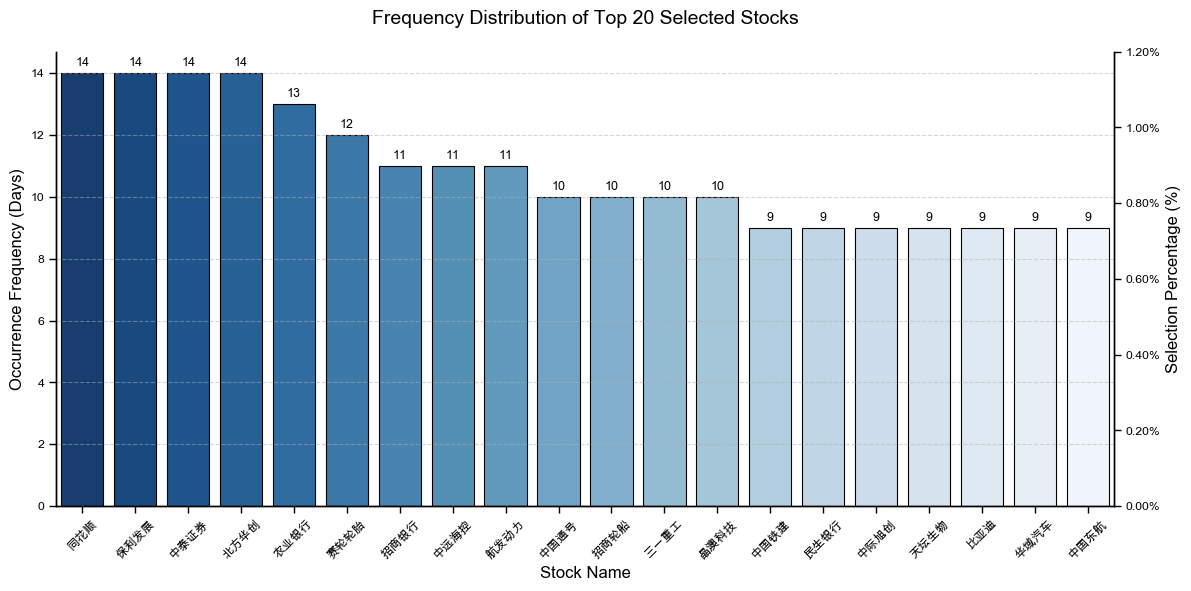

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 设置学术风格
sns.set_context("paper") # 自动调整线宽和字体大小适合论文
plt.rcParams['font.family'] = ['Arial Unicode MS', 'SimHei', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False

plot_data = selection_counts.head(n)

fig, ax1 = plt.subplots(figsize=(12, 6))

# 绘制柱状图
# 使用 'rocket' 或 'mako' 也是不错的学术选择
# 这里推荐使用单色渐变，避免颜色过多干扰读者
sns.barplot(
    x='Stock Name', 
    y='Occurrence Days', 
    data=plot_data, 
    palette='Blues_r', # 颜色由深变浅，层次分明
    ax=ax1,
    edgecolor='black',
    linewidth=0.8
)

# 设置标题和标签 (去掉粗体，学术论文通常使用常规体或更严谨的字体)
ax1.set_title(f'Frequency Distribution of Top {n} Selected Stocks', fontsize=14, pad=20)
ax1.set_xlabel('Stock Name', fontsize=12)
ax1.set_ylabel('Occurrence Frequency (Days)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 次坐标轴处理
ax2 = ax1.twinx()
ax2.set_ylabel('Selection Percentage (%)', fontsize=12)

total_days = len(top_1_report)
ax2.set_ylim(ax1.get_ylim()[0] / total_days * 100, ax1.get_ylim()[1] / total_days * 100)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# 标注数值
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', 
                     fontsize=9, 
                     xytext=(0, 3), 
                     textcoords='offset points')

# 网格线稍微加深一点点，增强可读性
ax1.yaxis.grid(True, linestyle='--', alpha=0.5) 
sns.despine(right=False)

plt.tight_layout()
plt.savefig('stock_selection_academic.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 计算每只股票的合计收益 (Sum of target)
# 我们按股票名称分组，对 target 列求和
profit_attribution = top_1_report.groupby('sec_name')[target].sum().reset_index()
profit_attribution.columns = ['Stock Name', 'Total Contribution Return']

# 2. 结合之前的出现次数 (Occurrence Days)
# 这样你可以看到：它是靠“涨幅大”赢的，还是靠“出现次数多”赢的
profit_attribution = profit_attribution.merge(selection_counts[['Stock Name', 'Occurrence Days']], on='Stock Name')

# 3. 按合计收益降序排列
profit_attribution = profit_attribution.sort_values(by='Total Contribution Return', ascending=False)

# 4. 打印前 15 名“功臣”股票
print("Top 15 Profit Contributors (Sorted by Total Return):")
print(profit_attribution.head(15))


Top 15 Profit Contributors (Sorted by Total Return):
    Stock Name  Total Contribution Return  Occurrence Days
218       澜起科技                   0.380983               12
137       天孚通信                   0.363745               14
148      寒武纪-U                   0.339214                9
54        中微公司                   0.305702               18
207       海光信息                   0.290210               11
16        东方财富                   0.288700               20
245       豪威集团                   0.277105               14
31        中国卫通                   0.267361               17
172       招商轮船                   0.215583               16
183       昆仑万维                   0.207451               10
3          三六零                   0.205477               13
99        华勤技术                   0.201044               12
81        信达证券                   0.197177               18
208       海南机场                   0.196428               13
70        云铝股份                   0.196153               18


## 回测

In [ ]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 初始化并加载模型
device = torch.device( "cpu")
model = QuantHybridModel(hf_input_dim=5, lf_input_dim=6).to(device)
model.load_state_dict(torch.load('model_final.pth')) # 换成你的文件名
model.eval()

# 2. 准备特征名称列表 (必须和你训练时的顺序一致)
# 假设前128个是LSTM提取的抽象特征，后16个是MLP处理后的财务特征
hf_feature_names = col_hf
lf_feature_names = col_lf

all_feature_names = hf_feature_names + lf_feature_names

# 3. 提取权重
with torch.no_grad():
    # 这里的 test_x_hf 和 test_x_lf 是你测试集的数据 tensor
    preds, weights = model(test_x_hf.to(device), test_x_lf.to(device))
    
    # 计算所有样本的平均权重
    avg_weights = weights.mean(dim=0).cpu().numpy()

# 4. 绘图：重点展示财务特征的权重
# 因为时序特征是抽象的，我们重点看最后6个财务特征的占比
plt.figure(figsize=(10, 6))
plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决中文乱码

# 提取最后6个财务指标的权重进行对比
fin_weights = avg_weights[-6:]
sns.barplot(x=fin_weights, y=lf_feature_names, palette="rocket")

plt.title("会计基本面指标在模型决策中的重要性权重 (Attention Analysis)")
plt.xlabel("平均注意力权重 (Sigmoid Score)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def plot_backtest_results(model_preds, real_returns, benchmark_prices):
    """
    model_preds: 模型预测的下一期收益率 (Array)
    real_returns: 对应的实际下一期收益率 (Array)
    benchmark_prices: 沪深300指数的收盘价序列 (Series)
    """
    # 策略逻辑：简单起见，假设我们每天/月买入模型预测涨幅最大的前10%股票
    # 这里我们计算一个模拟的策略收益：
    # 如果预测值为正且很大，我们就重仓；反之轻仓
    
    # 1. 转化为策略收益率 (这里简化处理，实际可以按Top-N选股计算)
    strat_daily_rets = model_preds * real_returns 
    
    # 2. 计算累计净值
    cum_strat = (1 + strat_daily_rets).cumprod()
    # 基准净值归一化
    cum_benchmark = benchmark_prices / benchmark_prices.iloc[0]
    
    # 3. 绘图
    plt.figure(figsize=(12, 6))
    plt.plot(cum_strat.values, label='本文融合模型 (CNN-LSTM-Fundamental)', color='#d62728', linewidth=2)
    plt.plot(cum_benchmark.values, label='沪深300基准 (CSI 300)', color='#7f7f7f', linestyle='--')
    
    plt.title("投资策略累计净值走势对比 (Backtesting Performance)")
    plt.ylabel("累计净值 (Standardized)")
    plt.xlabel("交易时间周期")
    plt.legend()
    plt.fill_between(range(len(cum_strat)), cum_strat, cum_benchmark, 
                     where=(cum_strat > cum_benchmark), color='red', alpha=0.1)
    plt.tight_layout()
    plt.show()

## 画图

findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family 'SimHei' not found.
findfont: Generic family 'sans-serif' not found because none of the fo

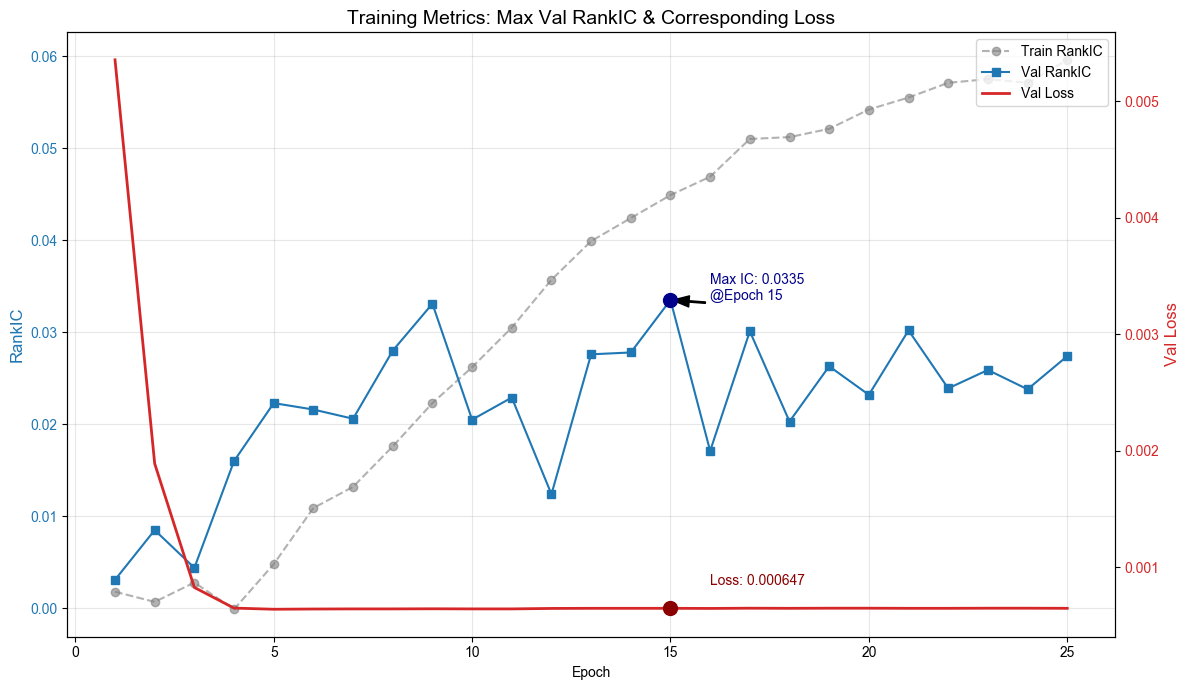

最佳周期 (Best Epoch): 15
最大验证集 IC (Max Val RankIC): 0.0335
对应的验证集 Loss (Val Loss at this epoch): 0.000647


In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 构建数据
data = {
    'Epoch': list(range(1, 26)),
    'Train_RankIC': [
        0.0018, 0.0007, 0.0028, -0.0001, 0.0048, 0.0109, 0.0132, 0.0176, 0.0223, 0.0262,
        0.0305, 0.0357, 0.0399, 0.0424, 0.0449, 0.0469, 0.0510, 0.0512, 0.0521, 0.0542,
        0.0555, 0.0571, 0.0575, 0.0571, 0.0596
    ],
    'Val_RankIC': [
        0.0031, 0.0085, 0.0044, 0.0160, 0.0223, 0.0216, 0.0206, 0.0280, 0.0331, 0.0205,
        0.0229, 0.0124, 0.0276, 0.0278, 0.0335, 0.0171, 0.0301, 0.0203, 0.0263, 0.0232,
        0.0302, 0.0239, 0.0259, 0.0238, 0.0274
    ],
    'Val_Loss': [
        0.005355, 0.001889, 0.000826, 0.000649, 0.000639, 0.000641, 0.000642, 0.000642, 
        0.000643, 0.000642, 0.000642, 0.000646, 0.000647, 0.000647, 0.000647, 0.000646, 
        0.000648, 0.000647, 0.000648, 0.000648, 0.000647, 0.000647, 0.000648, 0.000648, 0.000647
    ]
}

df = pd.DataFrame(data)

# --- 核心逻辑：寻找最大 Val RankIC 及其对应的 Loss ---
best_idx = df['Val_RankIC'].idxmax()
best_epoch = df.loc[best_idx, 'Epoch']
best_ic = df.loc[best_idx, 'Val_RankIC']
best_loss = df.loc[best_idx, 'Val_Loss']

# 2. 绘图
fig, ax1 = plt.subplots(figsize=(12, 7))

# 绘制 RankIC (左轴)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('RankIC', color='tab:blue', fontsize=12)
ax1.plot(df['Epoch'], df['Train_RankIC'], label='Train RankIC', color='tab:grey', linestyle='--', marker='o', alpha=0.6)
ax1.plot(df['Epoch'], df['Val_RankIC'], label='Val RankIC', color='tab:blue', linestyle='-', marker='s')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# 标注最大 RankIC 点
ax1.scatter(best_epoch, best_ic, color='darkblue', s=100, zorder=5) 
ax1.annotate(f'Max IC: {best_ic:.4f}\n@Epoch {best_epoch}', 
             xy=(best_epoch, best_ic), 
             xytext=(best_epoch + 1, best_ic),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, fontweight='bold', color='darkblue')

# 绘制 Loss (右轴)
ax2 = ax1.twinx() 
ax2.set_ylabel('Val Loss', color='tab:red', fontsize=12)
ax2.plot(df['Epoch'], df['Val_Loss'], label='Val Loss', color='tab:red', linestyle='-', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

# 标注对应的 Loss 点
ax2.scatter(best_epoch, best_loss, color='darkred', s=100, zorder=5)
ax2.annotate(f'Loss: {best_loss:.6f}', 
             xy=(best_epoch, best_loss), 
             xytext=(best_epoch + 1, best_loss + 0.0002), # 稍微偏移避免重叠
             fontsize=10, fontweight='bold', color='darkred')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Training Metrics: Max Val RankIC & Corresponding Loss', fontsize=14)
fig.tight_layout()
plt.show()

# 控制台打印结果确认
print(f"最佳周期 (Best Epoch): {best_epoch}")
print(f"最大验证集 IC (Max Val RankIC): {best_ic}")
print(f"对应的验证集 Loss (Val Loss at this epoch): {best_loss}")

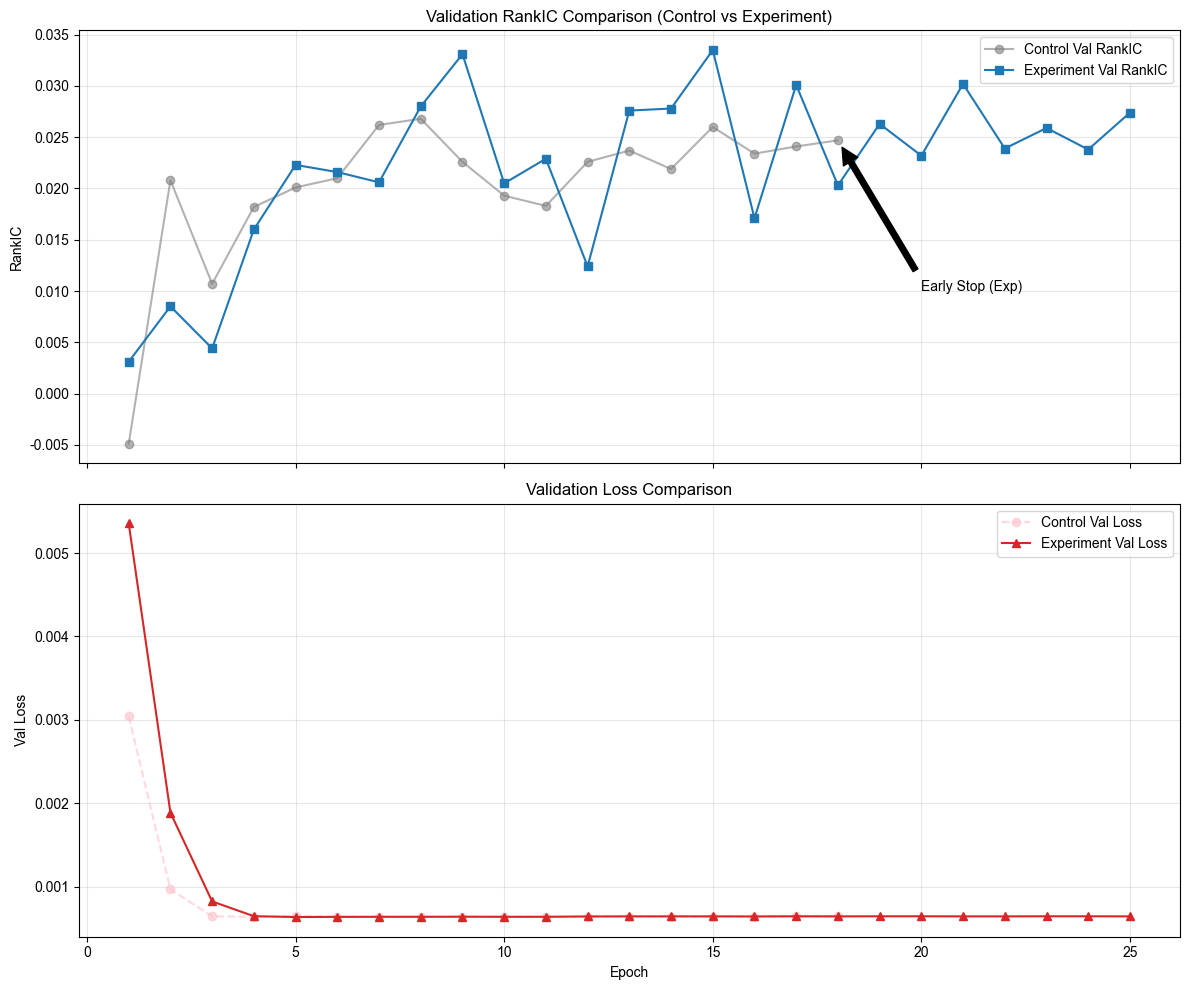

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 对照组数据 (从你的日志提取) ---
control_data = {
    'Epoch': list(range(1, 19)),
    'Train_RankIC': [0.0028, 0.0010, 0.0066, 0.0121, 0.0156, 0.0160, 0.0157, 0.0168, 0.0186, 0.0184, 0.0192, 0.0205, 0.0200, 0.0207, 0.0218, 0.0224, 0.0220, 0.0224],
    'Val_RankIC': [-0.0049, 0.0208, 0.0107, 0.0182, 0.0201, 0.0210, 0.0262, 0.0268, 0.0226, 0.0193, 0.0183, 0.0226, 0.0237, 0.0219, 0.0260, 0.0234, 0.0241, 0.0247],
    'Val_Loss': [0.003043, 0.000970, 0.000648, 0.000642, 0.000654, 0.000643, 0.000641, 0.000640, 0.000642, 0.000641, 0.000642, 0.000643, 0.000642, 0.000642, 0.000645, 0.000644, 0.000647, 0.000646]
}

# --- 2. 实验组数据 (你提供的代码部分) ---
exp_data = {
    'Epoch': list(range(1, 26)),
    'Train_RankIC': [0.0018, 0.0007, 0.0028, -0.0001, 0.0048, 0.0109, 0.0132, 0.0176, 0.0223, 0.0262, 0.0305, 0.0357, 0.0399, 0.0424, 0.0449, 0.0469, 0.0510, 0.0512, 0.0521, 0.0542, 0.0555, 0.0571, 0.0575, 0.0571, 0.0596],
    'Val_RankIC': [0.0031, 0.0085, 0.0044, 0.0160, 0.0223, 0.0216, 0.0206, 0.0280, 0.0331, 0.0205, 0.0229, 0.0124, 0.0276, 0.0278, 0.0335, 0.0171, 0.0301, 0.0203, 0.0263, 0.0232, 0.0302, 0.0239, 0.0259, 0.0238, 0.0274],
    'Val_Loss': [0.005355, 0.001889, 0.000826, 0.000649, 0.000639, 0.000641, 0.000642, 0.000642, 0.000643, 0.000642, 0.000642, 0.000646, 0.000647, 0.000647, 0.000647, 0.000646, 0.000648, 0.000647, 0.000648, 0.000648, 0.000647, 0.000647, 0.000648, 0.000648, 0.000647]
}

df_ctrl = pd.DataFrame(control_data)
df_exp = pd.DataFrame(exp_data)

# --- 3. 绘图比较 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 子图 1: RankIC 比较
ax1.plot(df_ctrl['Epoch'], df_ctrl['Val_RankIC'], 'o-', label='Control Val RankIC', color='gray', alpha=0.6)
ax1.plot(df_exp['Epoch'], df_exp['Val_RankIC'], 's-', label='Experiment Val RankIC', color='tab:blue')
ax1.set_ylabel('RankIC')
ax1.set_title('Validation RankIC Comparison (Control vs Experiment)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 子图 2: Loss 比较
ax2.plot(df_ctrl['Epoch'], df_ctrl['Val_Loss'], 'o--', label='Control Val Loss', color='pink', alpha=0.6)
ax2.plot(df_exp['Epoch'], df_exp['Val_Loss'], '^-', label='Experiment Val Loss', color='tab:red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Val Loss')
ax2.set_title('Validation Loss Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 标记早停点
ax1.annotate('Early Stop (Exp)', xy=(18, 0.0247), xytext=(20, 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

In [120]:
print(df_result.columns)

Index(['date', 'WEST_NETPROFIT_FY1_CHG_3M', 'WEST_NETPROFIT_FTM_CHG_3M',
       'WEST_SALES_FY1_3M', 'WEST_SALES_FTM_CHG_3M', 'VAL_AVGPE_SW', 'PE_TTM',
       'VAL_STDPE_SW', 'DFA_TLTSHARE', 'FA_ROE_AVG', 'FA_DEBTTOASSET',
       'FA_ORGR_TTM', 'FA_CTOP', 'code', 'OUTMESSAGE', 'OPEN', 'HIGH', 'LOW',
       'CLOSE', 'VOLUME', 'AMT', 'target_return', 'pred_score',
       'pred_score_time'],
      dtype='object')


In [121]:
import numpy as np
import pandas as pd

def calculate_model_metrics(df):
    # 定义计算每日 IC 的函数
    def daily_metrics(group):
        ic = group['pred_score'].corr(group['target_return'])
        rank_ic = group['pred_score'].corr(group['target_return'], method='spearman')
        return pd.Series({'IC': ic, 'RankIC': rank_ic})

    # 按日期分组计算
    daily_ic = df.groupby('date').apply(daily_metrics)

    # 计算综合指标
    metrics = {
        'Mean IC': daily_ic['IC'].mean(),
        'Mean RankIC': daily_ic['RankIC'].mean(),
        'ICIR': daily_ic['IC'].mean() / daily_ic['IC'].std(),
        'RankICIR': daily_ic['RankIC'].mean() / daily_ic['RankIC'].std(),
        'IC Winning Rate': (daily_ic['IC'] > 0).mean(),
    }
    
    return pd.DataFrame(metrics, index=['Value']).T, daily_ic

metrics_table, daily_ic_series = calculate_model_metrics(df_result)
print(metrics_table)

                    Value
Mean IC          0.009227
Mean RankIC      0.006686
ICIR             0.163558
RankICIR         0.113994
IC Winning Rate  0.551020


/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_49235/2544311372.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(daily_metrics)


In [123]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

def calculate_academic_metrics(df, pred_col, target_col='target_return'):
    """
    计算单组预测结果的学术指标
    """
    # --- A. 统计预测性能 (基于全样本) ---
    mse = mean_squared_error(df[target_col], df[pred_col])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(df[target_col], df[pred_col])
    r2 = r2_score(df[target_col], df[pred_col])

    # --- B. 序值相关性 (基于每日截面计算后取均值) ---
    def daily_corr(group):
        # Pearson IC
        ic = group[pred_col].corr(group[target_col])
        # Spearman RankIC
        rank_ic = group[pred_col].corr(group[target_col], method='spearman')
        return pd.Series({'IC': ic, 'RankIC': rank_ic})

    # 按天计算 IC 和 RankIC
    daily_metrics = df.groupby('date').apply(daily_corr, include_groups=False)
    
    mean_ic = daily_metrics['IC'].mean()
    mean_rank_ic = daily_metrics['RankIC'].mean()
    
    # 计算 ICIR (均值 / 标准差)
    icir = daily_metrics['IC'].mean() / daily_metrics['IC'].std() if daily_metrics['IC'].std() != 0 else 0
    rank_icir = daily_metrics['RankIC'].mean() / daily_metrics['RankIC'].std() if daily_metrics['RankIC'].std() != 0 else 0
    
    # IC 胜率
    ic_win_rate = (daily_metrics['IC'] > 0).mean()

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R-Squared': r2,
        'Mean IC': mean_ic,
        'Mean RankIC': mean_rank_ic,
        'ICIR': icir,
        'RankICIR': rank_icir,
        'IC Win-Rate': ic_win_rate
    }

# 1. 分别计算实验组和对照组
results_my_model = calculate_academic_metrics(df_result, 'pred_score')
results_baseline = calculate_academic_metrics(df_result, 'pred_score_time')

# 2. 汇总成学术论文风格的表格
final_table = pd.DataFrame({
    'Metric (指标)': [
        'Statistical: MSE ↓', 
        'Statistical: RMSE ↓', 
        'Statistical: MAE ↓', 
        'Statistical: R² ↑',
        'Information: Mean IC ↑', 
        'Information: Mean RankIC ↑', 
        'Information: ICIR ↑', 
        'Information: RankICIR ↑',
        'Information: IC Win-Rate ↑'
    ],
    'Baseline (对照组)': [
        results_baseline['MSE'], results_baseline['RMSE'], results_baseline['MAE'], results_baseline['R-Squared'],
        results_baseline['Mean IC'], results_baseline['Mean RankIC'], results_baseline['ICIR'], results_baseline['RankICIR'],
        results_baseline['IC Win-Rate']
    ],
    'Our Model (实验组)': [
        results_my_model['MSE'], results_my_model['RMSE'], results_my_model['MAE'], results_my_model['R-Squared'],
        results_my_model['Mean IC'], results_my_model['Mean RankIC'], results_my_model['ICIR'], results_my_model['RankICIR'],
        results_my_model['IC Win-Rate']
    ]
})

# 3. 格式化输出
# 设置保留4到6位小数，方便论文直接引用
pd.options.display.float_format = '{:.6f}'.format
print("=== 学术论文模型评价对比表 ===")
print(final_table)

# 4. 导出为 Excel 方便贴进 Word 论文
final_table.to_excel("model_performance_comparison.xlsx", index=False)

=== 学术论文模型评价对比表 ===
                  Metric (指标)  Baseline (对照组)  Our Model (实验组)
0          Statistical: MSE ↓        0.000525         0.000530
1         Statistical: RMSE ↓        0.022919         0.023011
2          Statistical: MAE ↓        0.014889         0.014923
3           Statistical: R² ↑       -0.008389        -0.016490
4      Information: Mean IC ↑        0.007333         0.009227
5  Information: Mean RankIC ↑        0.005036         0.006686
6         Information: ICIR ↑        0.110333         0.163558
7     Information: RankICIR ↑        0.075038         0.113994
8  Information: IC Win-Rate ↑        0.546939         0.551020
